In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import total_return,sharpe_ratio,max_drawdown

In [4]:
df=load_data("SPY")
print(df.head())

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.888153  296.906448  294.749706  295.672721  59151200
2020-01-03  294.640015  295.764082  293.442850  293.497680  77709700
2020-01-06  295.764069  295.846313  292.766557  292.885364  55653900
2020-01-07  294.932465  295.672695  294.484651  295.197466  40496400
2020-01-08  296.504272  297.719704  294.877590  295.124324  68296000


In [5]:
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()

df["Signal"] = 0
df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1

df[["Close", "SMA_50", "SMA_200", "Signal"]].tail()

Price,Close,SMA_50,SMA_200,Signal
Ticker,SPY,,,
Date,,,,
2026-06-04,757.090027,711.897201,681.049081,1
2026-06-05,737.549988,713.511801,681.564688,1
2026-06-08,739.219971,715.394399,682.097073,1
2026-06-09,737.049988,717.453599,682.631301,1
2026-06-10,725.429993,719.322799,683.059038,1


In [6]:
df["Returns"] = df["Close"].pct_change()

df["Strategy_Returns"] = (
    df["Signal"] * df["Returns"]
)

df[["Returns", "Strategy_Returns"]].head()

Price,Returns,Strategy_Returns
Ticker,,
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.007572,-0.0
2020-01-06,0.003815,0.0
2020-01-07,-0.002812,-0.0
2020-01-08,0.005329,0.0


In [7]:
df["Equity"] = (
    1 + df["Strategy_Returns"]
).cumprod()

df["Market"] = (
    1 + df["Returns"]
).cumprod()

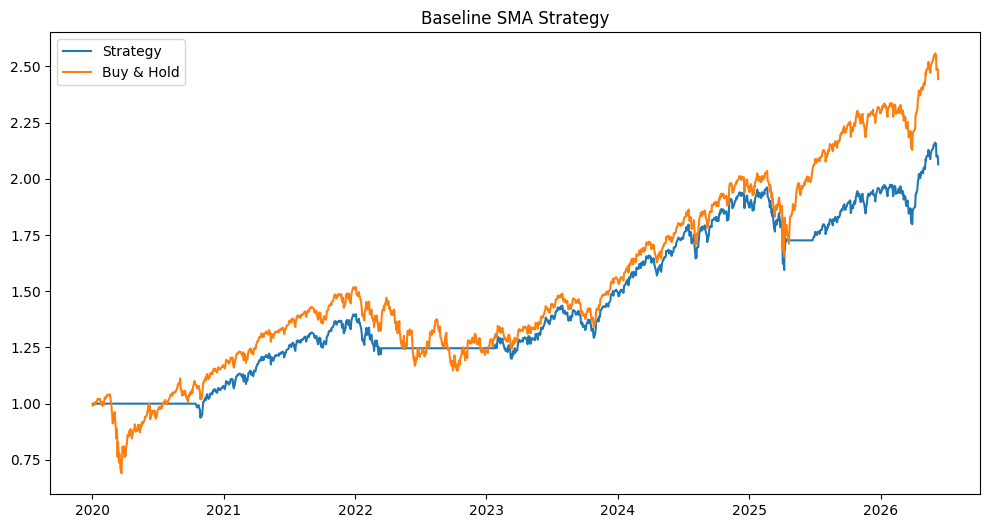

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Equity"], label="Strategy")
plt.plot(df.index, df["Market"], label="Buy & Hold")

plt.title("Baseline SMA Strategy")
plt.legend()
plt.show()

In [9]:
returns = df["Strategy_Returns"].dropna()

print("Total Return:",
      round(total_return(df["Equity"]) * 100, 2), "%")

print("Sharpe Ratio:",
      round(sharpe_ratio(returns), 2))

print("Max Drawdown:",
      round(max_drawdown(df["Equity"]) * 100, 2), "%")

Total Return: nan %
Sharpe Ratio: 0.96
Max Drawdown: -18.76 %
